In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## SQ pathways distribution by Phylum

In [2]:
# Extract phylum
final_table = pd.read_csv("../data/final_table.csv")

final_table["phylum"] = final_table["taxonomy"].str.extract(r"p__([^;]+)")

# Count loci for each pathway/taxon pair and sort
taxa_counts = final_table.groupby(["SQ_pathway", "phylum"]).size().reset_index(name="count")
taxa_counts_sorted = taxa_counts.sort_values("count", ascending=False).reset_index(drop=True)

print(taxa_counts_sorted)

    SQ_pathway             phylum  count
0    sulfo-EMP          Bacillota    151
1    sulfo-TAL          Bacillota    151
2     sulfo-TK          Bacillota     50
3    sulfo-TAL     Actinomycetota     10
4    sulfo-TAL     Pseudomonadota      9
5    sulfo-EMP      Chloroflexota      8
6   sulfo-ASMO     Actinomycetota      5
7    sulfo-TAL   Thermoplasmatota      4
8    sulfo-EMP      Spirochaetota      4
9    sulfo-TAL      Chloroflexota      3
10    sulfo-TK      Spirochaetota      2
11   sulfo-EMP     Actinomycetota      2
12    sulfo-ED          Bacillota      1
13   sulfo-EMP  Verrucomicrobiota      1


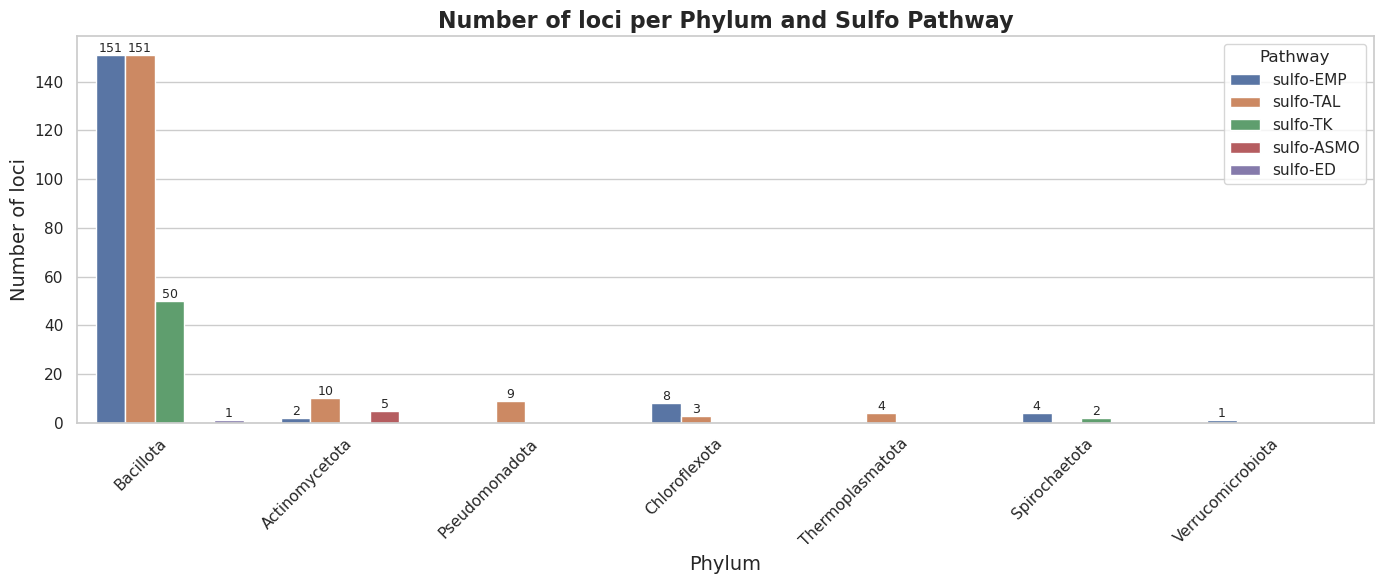

In [3]:
# Use the prepared table with all counts
plot_df = taxa_counts_sorted.copy()  # phylum, SQ_pathway, count

# Graph setup
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.barplot(data=plot_df, x="phylum", y="count", hue="SQ_pathway", dodge=True)  # Column: x = phylum, y = count, color = pathway

# Sign values of Y above the columns (only if count > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', fontsize=9
        )

plt.xticks(rotation=45, ha="right")
plt.xlabel("Phylum", fontsize=14)
plt.ylabel("Number of loci", fontsize=14)
plt.title("Number of loci per Phylum and Sulfo Pathway", fontsize=16, fontweight='bold')
plt.legend(title="Pathway")
plt.tight_layout()

# Save
plt.savefig("../pictures/distribution_analysis/sulfo_pathways_by_phylum.png", dpi=300)
# plt.savefig("../pictures/distribution_analysis/sulfo_pathways_by_phylum.pdf")

plt.show()

## SQ pathways distribution by Order

In [4]:
#  Extract order
final_table['order'] = final_table['taxonomy'].str.extract(r'o__([^;]+)')

# Count loci for each pathway/taxon pair and sort
order_taxa_counts = final_table.groupby(["SQ_pathway", "order"]).size().reset_index(name="count")
order_taxa_counts_sorted = order_taxa_counts.sort_values("count", ascending=False).reset_index(drop=True)

print(order_taxa_counts_sorted)

    SQ_pathway                    order  count
0    sulfo-EMP          Oscillospirales     80
1    sulfo-TAL           Lachnospirales     80
2     sulfo-TK          Oscillospirales     39
3    sulfo-TAL          Oscillospirales     36
4    sulfo-EMP           Lachnospirales     29
5    sulfo-EMP       Christensenellales     23
6    sulfo-TAL     Peptostreptococcales     10
7    sulfo-TAL         Coriobacteriales     10
8    sulfo-TAL         Enterobacterales      9
9    sulfo-EMP           Anaerolineales      8
10   sulfo-TAL       Erysipelotrichales      6
11    sulfo-TK       Christensenellales      6
12    sulfo-TK           Lachnospirales      5
13   sulfo-EMP             Monoglobales      5
14  sulfo-ASMO          Mycobacteriales      4
15   sulfo-EMP         Sphaerochaetales      4
16   sulfo-EMP                    RFN20      4
17   sulfo-TAL  Methanomassiliicoccales      4
18   sulfo-EMP                  UBA1381      3
19   sulfo-TAL       Christensenellales      3
20   sulfo-TA

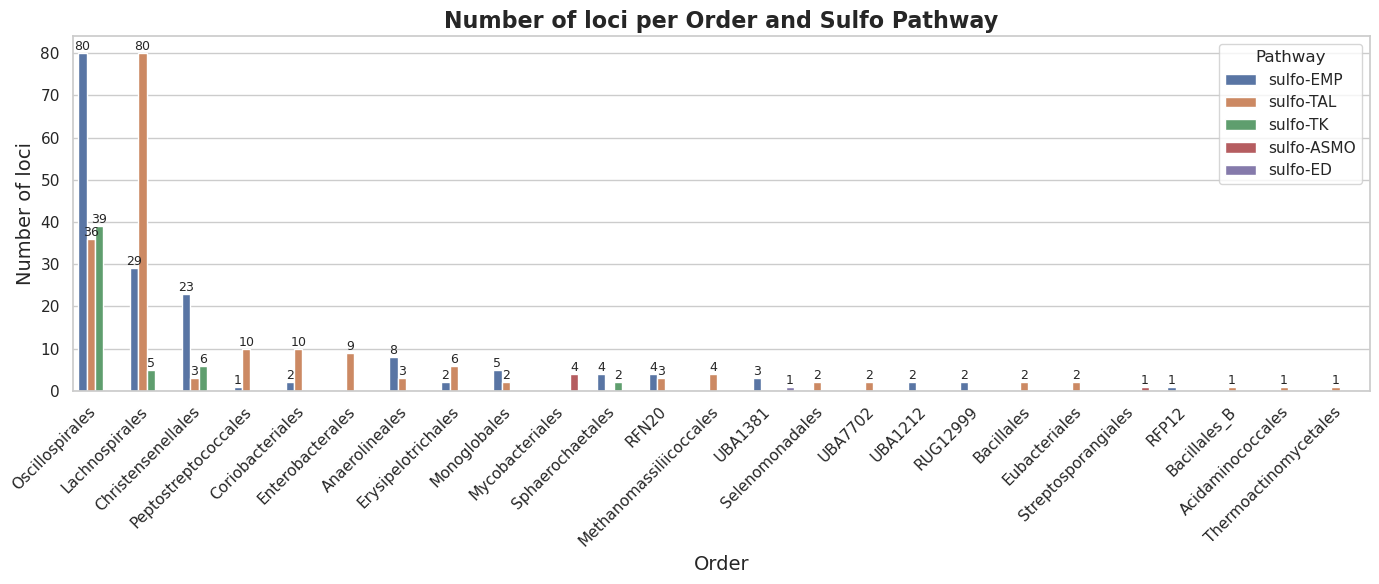

In [5]:
# Use the prepared table with all counts
plot_df = order_taxa_counts_sorted.copy()  # phylum, SQ_pathway, count

# graph setup
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# column: x = order, y = count, color = pathway
ax = sns.barplot(data=plot_df, x="order", y="count", hue="SQ_pathway", dodge=True)

# sign values of Y above the columns (only if count > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', fontsize=9
        )

plt.xticks(rotation=45, ha="right")
plt.xlabel("Order", fontsize=14)
plt.ylabel("Number of loci", fontsize=14)
plt.title("Number of loci per Order and Sulfo Pathway", fontsize=16, fontweight='bold')
plt.legend(title="Pathway")
plt.tight_layout()

# Save
plt.savefig("../pictures/distribution_analysis/sulfo_pathways_by_order.png", dpi=300)
# plt.savefig("../pictures/distribution_analysis/sulfo_pathways_by_phylum.pdf")

plt.show()

## Percentage distribution of Orders in the most represented pathways (sulfo-EMP, sulfo-TAL, sulfo-TK)

In [6]:
df_filtered = pd.read_csv("../data/clusters_filtered.csv")

In [7]:
order_to_color = {
    "Acidaminococcales": "#42855a",
    "Christensenellales": "#ffa7a7",
    "Eubacteriales": "#0b731e",
    "Lachnospirales": "#83adff",
    "Monoglobales": "#6d54b8",
    "Oscillospirales": "#f9b775",
    "Peptostreptococcales": "#bfe085",
    "RUG12999": "#c38046",
    "Selenomonadales": "#7bbd8d",
    "UBA1212": "#5254a3",
    "UBA1381": "#ba5aa4",
    "UBA7702": "#4b7b78",
    "RFN20": "#deb887",           
    "Sphaerochaetales": "#add8e6",
    "Anaerolineales": "#c0e0b0",
    "Erysipelotrichales": "#f0c0d0"
}

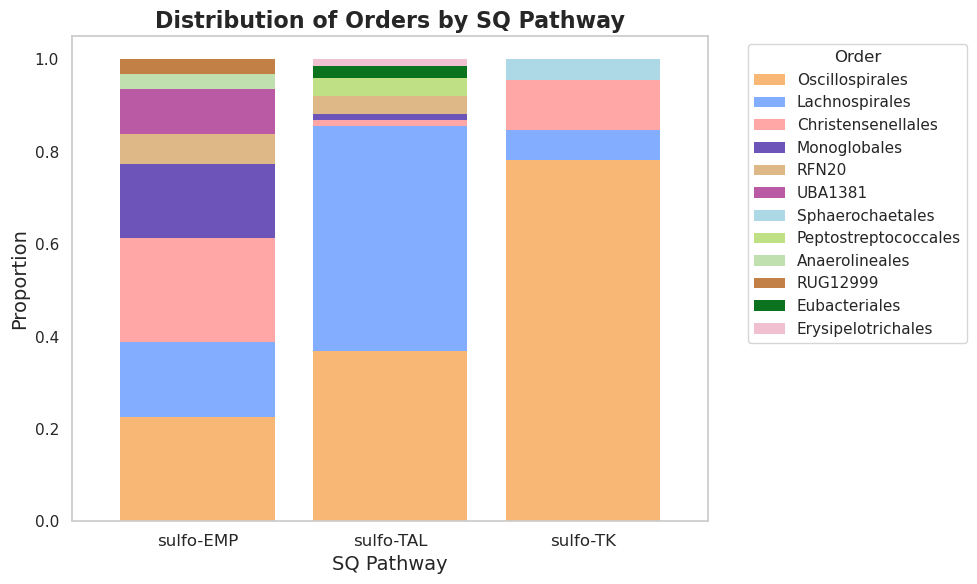

In [8]:
# Normalization
pivot_table_norm = pd.crosstab(df_filtered['SQ_pathway'], 
                                df_filtered['order'], 
                                normalize='index')

order_totals = pivot_table_norm.sum(axis=0).sort_values(ascending=False)
pivot_table_norm_sorted = pivot_table_norm[order_totals.index]

colors = [order_to_color[order] for order in pivot_table_norm_sorted.columns]

pivot_table_norm_sorted.plot(kind='bar', stacked=True, figsize=(10, 6), 
                              color=colors, width=0.8, edgecolor='none')

plt.title('Distribution of Orders by SQ Pathway', fontsize=16, fontweight='bold')
plt.xlabel('SQ Pathway', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.legend(title='Order', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.tight_layout()
plt.grid(False)
plt.savefig('../pictures/distribution_analysis/distribution_plot.png', dpi=300, bbox_inches='tight')
plt.show()